In [1]:
import flopy
import flopy.mf6 as mf6
import flopy.plot as fplt

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

import cartopy
import cartopy.crs as ccrs
from cartopy.io.img_tiles import GoogleTiles

import findwells as fw

After running the simulation, the outputs are saved to the output files directory. Luckily, you don't need to recreate and run the simulation every time you would like to visualize the outputs. 

Simply load in the simulation and grab the model objects, then retrieve the outputs from the model object!

## Load Simulation

In [2]:
# Load Simulation
sim = mf6.MFSimulation.load(sim_name='peterson', exe_name='../../mf6/mf6.exe', sim_ws='../input-files/')

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package riv...
    loading package obs...
    loading package wel...
    loading package chd...
    loading package sto...
    loading package rch...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading packag

## Load Models

In [3]:
# Grab groundwater flow model from simulation
gwf = sim.get_model('peterson_flow')

# Grab transport model for each solute
gwt_pfos = sim.get_model('peterson_pfos')
gwt_pfoa = sim.get_model('peterson_pfoa')
gwt_pfhxs = sim.get_model('peterson_pfhxs')

## Visualizing Head Data

In [4]:
# read head outputs from model object
head_obj = gwf.output.head()

# Load data from final timestep
heads = head_obj.get_data()

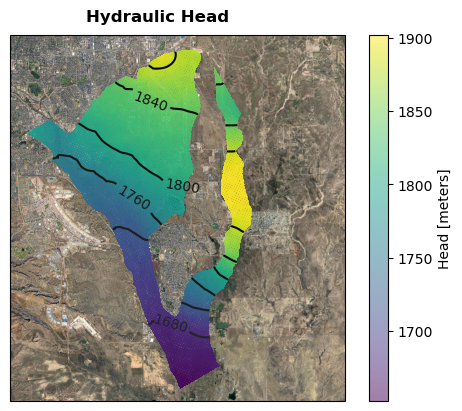

In [5]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained', figsize=(6,4), )#dpi=300)

modelmap = fplt.PlotMapView(model=gwf)

vmax = heads[heads!=1e30].max()
vmin = heads[heads!=1e30].min()
cellhead = modelmap.plot_array(heads[0], ax=ax, cmap='viridis', 
                               transform=ccrs.UTM(13), alpha=0.5)
fig.colorbar(cellhead, ax=ax, label='Head [meters]')

contour = modelmap.contour_array(heads[0], ax=ax, vmin=0,
                                 transform=ccrs.UTM(13), cmap='Grays')

ggtiles = GoogleTiles(style='satellite')
ax.add_image(ggtiles, 13)
ax.set_xlabel('Easting [meters]')
ax.set_ylabel('Northing [meters]')
ax.clabel(contour)

plt.suptitle('Hydraulic Head', weight='bold')
plt.show()

## Plot Flooded Cells

In [6]:
# Load in top elevation of layer
top_elev = np.loadtxt('../input-files/data-files/dis-top-elev.dat')

# Take difference between top elevation and head
diff = top_elev - heads[0]
diff_neg = np.where(diff < 0, diff, np.nan)  # Grab negative values (head > top)

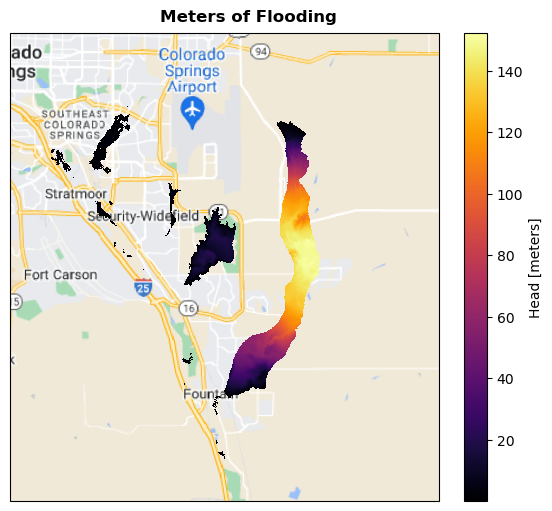

In [7]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained', figsize=(6,5))#, dpi=300)

modelmap = fplt.PlotMapView(model=gwf)

cellhead = modelmap.plot_array(-diff_neg, ax=ax, cmap='inferno', transform=ccrs.UTM(13))
fig.colorbar(cellhead, ax=ax, label='Head [meters]')

ggtiles = GoogleTiles()
ax.add_image(ggtiles, 11)
ax.set_xlabel('Easting [meters]')
ax.set_ylabel('Northing [meters]')

plt.suptitle('Meters of Flooding', weight='bold')
# plt.savefig('../figures/flooded-cells.png', bbox_inches='tight')
plt.show()

## Plot Observed vs Simulated Heads

In [8]:
# Read in simulated observations to a dataframe
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/head_obs.csv', isBinary=False)
sim_df = obs_out.get_dataframe()

In [9]:
# Set time index
sim_df.set_index('totim', inplace=True)
sim_df.head()

# Remove duplicate columns by keeping the first occurrence
sim_df = sim_df.loc[:, ~sim_df.columns.duplicated()]
sim_df.head()

,FOUNTAINNO.1,SC01406518ACDT02-MW006,SC01406518CAAMW1-1,SC01406519ABDT04-MW004,SC01406519BBBT01-MW002,SC01406520CDBMW2-4,SC01406527ACB1,SC01406527DDB1BANNING-LEWISRANCHES,SC01406527DDB2,SC01406527DDC1,...,SCO1506602BBBTH-18,SCO1506602BDC,SCO1506602CAA,SCO1506603AAD,SCO1506603BAC,SCO1506604AAA,SCO1506604AABTH-49,SCO1506604ABA2TH-50,SCO1506610BAA,SCO1506611ABCTH-47
totim,,,,,,,,,,,,,,,,,,,,,
59.0,1681.987735,1883.974514,1877.745285,1855.669695,1860.766222,1841.273764,1819.584478,1811.700325,1809.746561,1807.650279,...,1778.666146,1770.321412,1769.961186,1772.251807,1763.170947,1764.173832,1762.194710,1762.218579,1749.725740,1751.961208
89.0,1681.974959,1883.970374,1877.738288,1855.606681,1860.751174,1841.147646,1819.704667,1811.782336,1809.864378,1807.751710,...,1778.639413,1770.300324,1769.937267,1772.232234,1763.119837,1763.941931,1762.523957,1762.589654,1749.724715,1751.953974
274.0,1681.862768,1883.904718,1877.597708,1854.899953,1860.330085,1840.018757,1819.729684,1812.105291,1810.300276,1808.226024,...,1777.847622,1769.784646,1769.504366,1771.614906,1762.710238,1763.545422,1762.444138,1762.537636,1749.707116,1751.819917
304.0,1681.838511,1883.894573,1877.575874,1854.842876,1860.304820,1839.908327,1819.716013,1812.158926,1810.365286,1808.296597,...,1777.788589,1769.743838,1769.453639,1771.581038,1762.658464,1763.489846,1762.431202,1762.528917,1749.706592,1751.796851
365.0,1681.805776,1883.876904,1877.545277,1854.660518,1860.233011,1839.538880,1819.695268,1812.239054,1810.471846,1808.419822,...,1777.521918,1769.593066,1769.327954,1771.390284,1762.560118,1763.425641,1762.416448,1762.518969,1749.702606,1751.747423


In [10]:
obs_df = pd.read_csv('../input-files/data-files/flow-observed-heads.csv', index_col='time')
obs_df.head()

,FOUNTAINNO.1,SC01406518ACDT02-MW006,SC01406518CAAMW1-1,SC01406519ABDT04-MW004,SC01406519BBBT01-MW002,SC01406520CDBMW2-4,SC01406527ACB1,SC01406527DDB1BANNING-LEWISRANCHES,SC01406527DDB2,SC01406527DDC1,...,SCO1506602BBBTH-18,SCO1506602BDC,SCO1506602CAA,SCO1506603AAD,SCO1506603BAC,SCO1506604AAA,SCO1506604AABTH-49,SCO1506604ABA2TH-50,SCO1506610BAA,SCO1506611ABCTH-47
time,,,,,,,,,,,,,,,,,,,,,
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
639,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1802.757888,1803.123648,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Align sim_df and obs_df by their common indices
common_index = sim_df.index.intersection(obs_df.index)

# Use only the rows corresponding to the common index
sim_df_aligned = sim_df.loc[common_index]
obs_df_aligned = obs_df.loc[common_index]

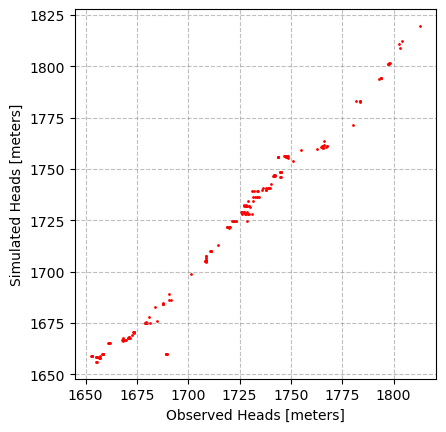

In [12]:
fig, ax = plt.subplots()

for col in sim_df.columns:
    if (col != 'SC01506614BBA TH-5') & (col != 'SC01606516CCC2'):
        ax.scatter(obs_df_aligned[col], sim_df_aligned[col], color='r', s=1)

    else:
        print(f"Well {col} not in both")

ax.set_xlabel('Observed Heads [meters]')
ax.set_ylabel('Simulated Heads [meters]')
ax.set_aspect('equal')
ax.grid(ls='--', color='gray', alpha=0.5)

## Plot Concentration Results

### PFOS Results

In [18]:
# Get solute concentrations
PFOS = gwt_pfos.output.concentration().get_alldata()
PFOA = gwt_pfoa.output.concentration().get_alldata()
#PFHxS = gwt_pfhxs.output.concentration().get_alldata()

In [ ]:
PFOS.shape, PFOA.shape, PFHxS.shape

In [24]:
downstream_wells = pd.read_csv('../input-files/data-files/tran-targets-downstream.csv')
upstream_well = pd.read_csv('../input-files/data-files/tran-PFOS-targets.csv') #, sheet_name='PFOS')

In [25]:
x = gwt_pfos.modelgrid.xcellcenters[downstream_wells['x'].to_numpy('int64'), downstream_wells['y'].to_numpy('int64')]
y = gwt_pfos.modelgrid.ycellcenters[downstream_wells['x'].to_numpy('int64'), downstream_wells['y'].to_numpy('int64')]

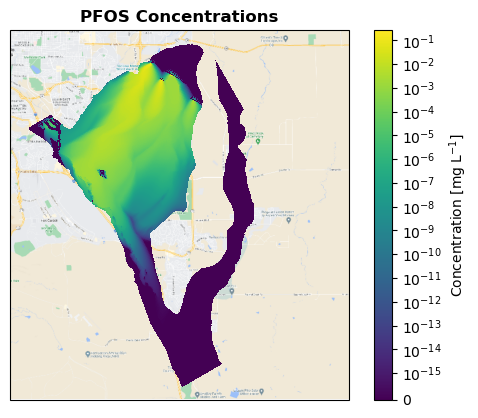

In [33]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)})

modelmap = fplt.PlotMapView(model=gwt_pfos)

vmax = PFOS[PFOS != 1e30].max()
norm = SymLogNorm(1e-15, vmin=0, vmax=vmax)
cs1 = modelmap.plot_array(PFOS[445], transform=ccrs.UTM(13), norm=norm)
fig.colorbar(cs1, ax=ax, label="Concentration [mg L$^{-1}$]")

#ax.scatter(upstream_well['x'], upstream_well['y'], label=upstream_well['Well_ID'], transform=ccrs.PlateCarree(), c=upstream_well['Result_ngL'], s=1, cmap='Reds', norm=SymLogNorm(linthresh=1e-9, vmin=0))

#ax.scatter(x, y, c=downstream_wells['PFOS (ng/L)'], transform=ccrs.UTM(13), cmap='Oranges', norm=SymLogNorm(linthresh=1e-9, vmin=0), s=1)



ggtiles = GoogleTiles()
ax.add_image(ggtiles, 13)
ax.set_title('PFOS Concentrations', weight='bold')
#plt.legend()

plt.show()

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained',)# figsize=(18, 5))

modelmap = fplt.PlotMapView(model=gwt_pfos)

# plot PFOS
vmax = PFOS[PFOS != 1e30].max()
norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
conc = modelmap.plot_array(PFOS[-1], ax=ax, cmap='inferno', norm=norm,
                               transform=ccrs.UTM(13))
fig.colorbar(conc, ax=ax, label='Concentration [mg/L]')

ggtiles = GoogleTiles(style='satellite')
ax.add_image(ggtiles, 13)
ax.set_title('PFOS Concentrations', weight='bold')

plt.show()

### Observed vs Simulated PFOS concentration

Day of sampling since model start: `17713`

In [ ]:
# Read in simulated observations to a dataframe
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/pfos_obs.csv', isBinary=False)
sim_wells = obs_out.get_dataframe()

closest_index = sim_wells.index[(np.abs(sim_wells.totim - 17713)).argmin()]
sim_results = sim_wells.loc[closest_index]

In [ ]:
obs_wells = pd.read_csv('../input-files/data-files/tran-targets-downstream.csv', index_col='Well Name')
obs_wells = obs_wells.T

In [ ]:
common_index = obs_wells.columns.intersection(sim_results.index)

sim_results = sim_results.loc[common_index] * 1e6
obs_results = obs_wells.T.loc[common_index, "PFOS (ng/L)"]

In [ ]:
obs = obs_results.to_numpy(dtype='float64')
sim = sim_results.to_numpy(dtype='float64')

names = obs_results.index  # Adjust this if names are in a specific column, e.g., obs_results['Name']

vmin = min(obs.min(), sim.min())
vmin = min(obs.min(), sim.min())
vmax = max(obs.max(), sim.max())
xy = np.linspace(vmin, vmax, 10)

fig, ax = plt.subplots()

ax.scatter(obs, sim, s=10, marker='x')
ax.plot(xy, xy, linestyle='--', c='k')
ax.grid(ls='--', color='grey', alpha=0.5)

ax.set_xlabel('Observed Concentration [ng L$^{-1}$]')
ax.set_ylabel('Simulated Concentration [ng L$^{-1}$]')

# Add labels for each point
for i, name in enumerate(names):
    ax.annotate(name, (obs[i], sim[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.show()

In [ ]:
pfos_us = pd.read_csv('../input-files/data-files/tran-PFOS-observations.csv')

In [ ]:
pfos_us['time'] = pd.to_datetime(pfos_us.time)

In [ ]:
pfos_us.set_index('time', inplace=True)

In [ ]:
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/pfos_obs.csv', isBinary=False)
sim_wells = obs_out.get_dataframe()

In [ ]:
# closest_index = sim_wells.index[(np.abs(sim_wells.totim - 17713)).argmin()]

closest_rows = []
for date in pfos_us.index:
    # Find the closest index in the reshaped DataFrame
    closest_index = sim_wells.index[(np.abs(sim_wells.index - date)).argmin()]
    
    # Store the closest date and row values
    closest_rows.append(closest_index)

In [ ]:
sim_wells_aligned = sim_wells.loc[closest_rows]
sim_wells_aligned.drop(columns='totim', axis=1, inplace=True)

In [ ]:
fig, ax = plt.subplots()

for col in sim_wells_aligned.columns:
    try:
        ax.scatter(pfos_us[col], sim_wells_aligned[col] * 1e6, color='r', s=1)
        well_names = pfos_us.columns  # Extract well names from the column headers
        
    except:
        print(f"Well {col} not in both")

#ax.set_xscale('log')  # Log scale for the x-axis

ax.set_xlabel('Observed Concentration [ng/l]')
ax.set_ylabel('Simulated Concentration [ng/l]')
# ax.set_aspect('equal')
ax.grid(ls='--', color='gray', alpha=0.5)

### PFOA Results

In [ ]:
PFOA.shape

In [ ]:
downstream_wells = pd.read_csv('../input-files/data-files/tran-targets-downstream.csv')
upstream_well = pd.read_excel('../input-files/data-files/tran-PFAS-targets.xlsx', sheet_name='PFOA')

In [ ]:
x = gwt_pfos.modelgrid.xcellcenters[downstream_wells['x'].to_numpy('int64'), downstream_wells['y'].to_numpy('int64')]
y = gwt_pfos.modelgrid.ycellcenters[downstream_wells['x'].to_numpy('int64'), downstream_wells['y'].to_numpy('int64')]

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, dpi=300)

modelmap = fplt.PlotMapView(model=gwt_pfoa)

vmax = PFOA[PFOA != 1e30].max()
norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
cs1 = modelmap.plot_array(PFOA[-1], transform=ccrs.UTM(13), norm=norm)
fig.colorbar(cs1, ax=ax, label="Concentration [mg L$^{-1}$]")

ax.scatter(upstream_well['x'], upstream_well['y'], label=upstream_well['Well_ID'], transform=ccrs.PlateCarree(), c=upstream_well['Result_ngL'], s=1, cmap='Reds', norm=SymLogNorm(linthresh=1e-9, vmin=0))

ax.scatter(x, y, c=downstream_wells['PFOA (ng/L)'], transform=ccrs.UTM(13), cmap='Oranges', norm=SymLogNorm(linthresh=1e-9, vmin=0), s=1)


ggtiles = GoogleTiles()
ax.add_image(ggtiles, 13)
ax.set_title('PFOA Concentrations', weight='bold')

plt.show()

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained',)# figsize=(18, 5))

modelmap = fplt.PlotMapView(model=gwt_pfos)

# plot PFOA
vmax = PFOA[PFOA != 1e30].max()
norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
conc = modelmap.plot_array(PFOA[-1], ax=ax, cmap='inferno', norm=norm,
                               transform=ccrs.UTM(13))
fig.colorbar(conc, ax=ax, label='Concentration [mg/L]')

ggtiles = GoogleTiles(style='satellite')
ax.add_image(ggtiles, 13)
ax.set_title('PFOA Concentrations', weight='bold')

plt.show()

### Observed vs Simulated PFOA concentration

In [ ]:
# Read in simulated observations to a dataframe
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/pfoa_obs.csv', isBinary=False)
sim_wells = obs_out.get_dataframe()

closest_index = sim_wells.index[(np.abs(sim_wells.totim - 17713)).argmin()]
sim_results = sim_wells.loc[closest_index]

In [ ]:
common_index = obs_wells.columns.intersection(sim_results.index)

sim_results = sim_results.loc[common_index] * 1e6
obs_results = obs_wells.T.loc[common_index, "PFOA (ng/L)"]

In [ ]:
obs = obs_results.to_numpy(dtype='float64')
sim = sim_results.to_numpy(dtype='float64')

names = obs_results.index  # Adjust this if names are in a specific column, e.g., obs_results['Name']

vmin = min(obs.min(), sim.min())
vmax = max(obs.max(), sim.max())
xy = np.linspace(vmin, vmax, 10)

fig, ax = plt.subplots()

ax.scatter(obs, sim, marker='x', s=10)
ax.plot(xy, xy, linestyle='--', c='k')
ax.grid(ls='--', color='grey', alpha=0.5)

ax.set_xlabel('Observed Concentration [ng L$^{-1}$]')
ax.set_ylabel('Simulated Concentration [ng L$^{-1}$]')

# Add labels for each point
for i, name in enumerate(names):
    ax.annotate(name, (obs[i], sim[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.show()

In [ ]:
pfoa_us = pd.read_csv('../input-files/data-files/tran-PFOA-observations.csv')

pfoa_us['time'] = pd.to_datetime(pfoa_us.time)

pfoa_us.set_index('time', inplace=True)

In [ ]:
# Not confident this cell needs to be in again
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/pfoa_obs.csv', isBinary=False)
sim_wells = obs_out.get_dataframe()

In [ ]:
# closest_index = sim_wells.index[(np.abs(sim_wells.totim - 17713)).argmin()]

closest_rows = []
for date in pfos_us.index:
    # Find the closest index in the reshaped DataFrame
    closest_index = sim_wells.index[(np.abs(sim_wells.index - date)).argmin()]
    
    # Store the closest date and row values
    closest_rows.append(closest_index)

In [ ]:
sim_wells_aligned = sim_wells.loc[closest_rows]
sim_wells_aligned.drop(columns='totim', axis=1, inplace=True)

In [ ]:
fig, ax = plt.subplots()

for col in sim_wells_aligned.columns:
    try:
        ax.scatter(pfoa_us[col], sim_wells_aligned[col] * 1e6, color='r', s=1)

    except:
        print(f"Well {col} not in both")

#ax.set_xscale('log')  # Log scale for the x-axis

ax.set_xlabel('Observed Concentration [ng/l]')
ax.set_ylabel('Simulated Concentration [ng/l]')
# ax.set_aspect('equal')
ax.grid(ls='--', color='gray', alpha=0.5)

### PFHxS Results

In [ ]:
PFHxS.shape

In [ ]:
downstream_wells = pd.read_csv('../input-files/data-files/tran-targets-downstream.csv')
upstream_well = pd.read_excel('../input-files/data-files/tran-PFAS-targets.xlsx', sheet_name='PFHxS')

In [ ]:
x = gwt_pfhxs.modelgrid.xcellcenters[downstream_wells['x'].to_numpy('int64'), downstream_wells['y'].to_numpy('int64')]
y = gwt_pfhxs.modelgrid.ycellcenters[downstream_wells['x'].to_numpy('int64'), downstream_wells['y'].to_numpy('int64')]

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, dpi=300)

modelmap = fplt.PlotMapView(model=gwt_pfos)

vmax = PFHxS[PFHxS != 1e30].max()
norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
cs1 = modelmap.plot_array(PFHxS[-1], transform=ccrs.UTM(13), norm=norm)
fig.colorbar(cs1, ax=ax, label="Concentration [mg L$^{-1}$]")

# cs1 = modelmap.plot_array(k, transform=ccrs.UTM(13))
# fig.colorbar(cs1, ax=ax, label="Concentration [mg L$^{-1}$]")

ax.scatter(upstream_well['x'], upstream_well['y'], label=upstream_well['Well_ID'], transform=ccrs.PlateCarree(), c=upstream_well['Result_ngL'], s=1, cmap='Reds', norm=SymLogNorm(linthresh=1e-9, vmin=0))

ax.scatter(x, y, c=downstream_wells['PFHxS (ng/L)'], transform=ccrs.UTM(13), cmap='Oranges', norm=SymLogNorm(linthresh=1e-9, vmin=0), s=1)


ggtiles = GoogleTiles()
ax.add_image(ggtiles, 13)
ax.set_title('PFHxS Concentrations', weight='bold')

plt.show()

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained',)# figsize=(18, 5))

modelmap = fplt.PlotMapView(model=gwt_pfhxs)

# plot PFOS
vmax = PFHxS[PFHxS != 1e30].max()
norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
conc = modelmap.plot_array(PFHxS[-1], ax=ax, cmap='inferno', norm=norm,
                               transform=ccrs.UTM(13))
fig.colorbar(conc, ax=ax, label='Concentration [mg/L]')

ggtiles = GoogleTiles(style='satellite')
ax.add_image(ggtiles, 13)
ax.set_title('PFHxS Concentrations', weight='bold')

plt.show()

### Observed vs Simulated PFHxS concentration

In [ ]:
# Read in simulated observations to a dataframe
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/pfhxs_obs.csv', isBinary=False)
sim_wells = obs_out.get_dataframe()

closest_index = sim_wells.index[(np.abs(sim_wells.totim - 17713)).argmin()]
sim_results = sim_wells.loc[closest_index]

In [ ]:
common_index = obs_wells.columns.intersection(sim_results.index)

sim_results = sim_results.loc[common_index] * 1e6
obs_results = obs_wells.T.loc[common_index, "PFHxS (ng/L)"]

In [ ]:
obs = obs_results.to_numpy(dtype='float64')
sim = sim_results.to_numpy(dtype='float64')

names = obs_results.index  # Adjust this if names are in a specific column, e.g., obs_results['Name']

vmin = min(obs.min(), sim.min())
vmax = max(obs.max(), sim.max())
xy = np.linspace(vmin, vmax, 10)

fig, ax = plt.subplots()

ax.scatter(obs, sim, s=10, marker='x')
ax.plot(xy, xy, linestyle='--', c='k')
ax.grid(ls='--', color='grey', alpha=0.5)

ax.set_xlabel('Observed Concentration [ng L$^{-1}$]')
ax.set_ylabel('Simulated Concentration [ng L$^{-1}$]')

# Add labels for each point
for i, name in enumerate(names):
    ax.annotate(name, (obs[i], sim[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.show()

In [ ]:
pfhxs_us = pd.read_csv('../input-files/data-files/tran-PFHxS-observations.csv')

pfhxs_us['SDate'] = pd.to_datetime(pfhxs_us.SDate)

pfhxs_us.set_index('SDate', inplace=True)

In [ ]:
obs_out = flopy.utils.observationfile.Mf6Obs('../output-files/pfhxs_obs.csv', isBinary=False)
sim_wells = obs_out.get_dataframe()

In [ ]:
# closest_index = sim_wells.index[(np.abs(sim_wells.totim - 17713)).argmin()]

closest_rows = []
for date in pfos_us.index:
    # Find the closest index in the reshaped DataFrame
    closest_index = sim_wells.index[(np.abs(sim_wells.index - date)).argmin()]
    
    # Store the closest date and row values
    closest_rows.append(closest_index)

In [ ]:
sim_wells_aligned = sim_wells.loc[closest_rows]
sim_wells_aligned.drop(columns='totim', axis=1, inplace=True)

In [ ]:
fig, ax = plt.subplots()

for col in sim_wells_aligned.columns:
    try:
        ax.scatter(pfhxs_us[col], sim_wells_aligned[col] * 1e6, color='r', s=1)

    except:
        print(f"Well {col} not in both")

#ax.set_xscale('log')  # Log scale for the x-axis

ax.set_xlabel('Observed Concentration [ng/l]')
ax.set_ylabel('Simulated Concentration [ng/l]')
# ax.set_aspect('equal')
ax.grid(ls='--', color='gray', alpha=0.5)

In [ ]:
import imageio

In [ ]:
# fig, axs = plt.subplots(ncols=3, subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained', figsize=(18, 5))
# ax1, ax2, ax3 = axs

# modelmap = fplt.PlotMapView(model=gwt_pfos)

# # plot PFOS
# vmax = PFOS[PFOS != 1e30].max()
# norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
# cellhead = modelmap.plot_array(PFOS[0], ax=ax1, cmap='inferno', norm=norm,
#                                transform=ccrs.UTM(13))
# fig.colorbar(cellhead, ax=ax1, label='Concentration [mg/L]')

# # Plot PFOA
# vmax = PFOA[PFOA != 1e30].max()
# norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
# cellhead = modelmap.plot_array(PFOA[0], ax=ax2, cmap='inferno', norm=norm, 
#                                transform=ccrs.UTM(13))
# fig.colorbar(cellhead, ax=ax2, label='Concentration [mg/L]')

# # Plot PFHxS
# vmax = PFHxS[PFHxS != 1e30].max()
# norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
# cellhead = modelmap.plot_array(PFHxS[0], ax=ax3, cmap='inferno', norm=norm, 
#                                transform=ccrs.UTM(13))
# fig.colorbar(cellhead, ax=ax3, label='Concentration [mg/L]')

# titles = ['PFOS Concentrations', 'PFOA Concentrations', 'PFHxS Concentrations']
# for ax, title in zip(axs, titles):
#     ggtiles = GoogleTiles(style='satellite')
#     ax.add_image(ggtiles, 13)
    
#     ax.set_title(title, weight='bold')

# plt.show()

In [ ]:
# for i in range(350):
#     fig, axs = plt.subplots(ncols=3, subplot_kw={'projection':ccrs.UTM(13)}, layout='constrained', figsize=(18, 5))
#     ax1, ax2, ax3 = axs
    
#     modelmap = fplt.PlotMapView(model=gwt_pfos)
    
#     # plot PFOS
#     vmax = PFOS[PFOS != 1e30].max()
#     norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
#     cellhead = modelmap.plot_array(PFOS[i][0], ax=ax1, cmap='inferno', norm=norm,
#                                    transform=ccrs.UTM(13))
#     fig.colorbar(cellhead, ax=ax1, label='Concentration [mg/L]')
    
#     # Plot PFOA
#     vmax = PFOA[PFOA != 1e30].max()
#     norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
#     cellhead = modelmap.plot_array(PFOA[i][0], ax=ax2, cmap='inferno', norm=norm, 
#                                    transform=ccrs.UTM(13))
#     fig.colorbar(cellhead, ax=ax2, label='Concentration [mg/L]')
    
#     # Plot PFHxS
#     vmax = PFHxS[PFHxS != 1e30].max()
#     norm = SymLogNorm(1e-9, vmin=0, vmax=vmax)
#     cellhead = modelmap.plot_array(PFHxS[i][0], ax=ax3, cmap='inferno', norm=norm, 
#                                    transform=ccrs.UTM(13))
#     fig.colorbar(cellhead, ax=ax3, label='Concentration [mg/L]')
    
#     titles = ['PFOS Concentrations', 'PFOA Concentrations', 'PFHxS Concentrations']
#     for ax, title in zip(axs, titles):
#         ggtiles = GoogleTiles(style='satellite')
#         ax.add_image(ggtiles, 13)
        
#         ax.set_title(title, weight='bold')
    
#     plt.savefig(f'../figures/gif-pngs/sp-{i}.png')
#     plt.close()

# pngs = [imageio.v2.imread(f'../figures/gif-pngs/sp-{i}.png') for i in range(350)]

# imageio.mimsave('../figures/concentrations.gif', pngs, duration=50, loop=0)

## Well Breakthrough Curves

In [ ]:
upstream = pd.read_excel('../input-files/data-files/tran-PFAS-targets.xlsx')
downstream = pd.read_csv('../input-files/data-files/tran-targets-downstream.csv')

In [ ]:
pfos_wells.loc[:, ['W8', 'W9', 'W12','S17']]

In [ ]:
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [ ]:
observations_pfos = pd.read_csv('../input-files/data-files/tran-PFOS-observations.csv')

In [ ]:
observations_pfos['SDate'] = pd.to_datetime(observations_pfos['SDate'])

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['MW-2'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'MW-2'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['MW-2'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')
ax.set_title('MW-2')



# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['PETER04-006'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'PETER04-006'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['PETER04-006'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')

ax.set_title('PETER04-006')
# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['PETER-T04-MW004'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'PETER-T04-MW004'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['PETER-T04-MW004'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')

ax.set_title('PETER-T04-MW004')
# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['MW1-7'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'MW1-7'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['MW1-7'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')

ax.set_title('MW1-7')

# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['MW1-6'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'MW1-6'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['MW1-7'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')

ax.set_title('MW1-6')

# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['MW-3'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'MW-3'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['MW-3'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')

ax.set_title('MW-3')

# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

In [ ]:
fig, ax = plt.subplots()

convertible_indexes = pfos_wells.index[pfos_wells['S17'].apply(is_convertible_to_float)].to_numpy()
well = pfos_wells.loc[convertible_indexes, 'S17'].to_numpy('float64')

# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.SDate, observations_pfos['S17'] * 1e-9, c='r')
ax.plot(date_indexes, well)#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
ax.set_xlabel('Days since 1970-01-01')

ax.set_title('S17')

# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()